# Random Forest Evaluation (Task 4, Part 4)

Train a random forest classifier on all eligible signals and compare its test-set ROC-AUC with the combined logistic regression model (Part 3) and the strongest individual signal (Part 2).

Input: `data/train_split.csv` and `data/test_split.csv` from `notebooks/002_build_dataset_and_split.ipynb` (84 train / 22 test repos, stratified, seed 42, no repository overlap).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv("../data/train_split.csv")
test_df = pd.read_csv("../data/test_split.csv")

print("Training repos:", len(train_df))
print("Test repos:", len(test_df))

Training repos: 84
Test repos: 22


## Sanity checks

Confirm the split matches what Part 1 reported: no repository in both sets, the expected label balance, and which signals have missing values.

In [2]:
train_names = set(train_df["full_name"])
test_names = set(test_df["full_name"])
overlap = train_names.intersection(test_names)
print("Repos in both sets:", len(overlap))

print()
print("Training label counts (1 = good, 0 = uncertain):")
print(train_df["target_label"].value_counts())

print()
print("Test label counts (1 = good, 0 = uncertain):")
print(test_df["target_label"].value_counts())

print()
print("Missing values in the training set:")
print(train_df.isna().sum().sum())

Repos in both sets: 0

Training label counts (1 = good, 0 = uncertain):
target_label
1    65
0    19
Name: count, dtype: int64

Test label counts (1 = good, 0 = uncertain):
target_label
1    17
0     5
Name: count, dtype: int64

Missing values in the training set:
0


## Features and target

The target is `target_label` (1 = good, 0 = uncertain). `full_name` is an identifier and `label` is the text version of the target, so both are excluded from the model inputs. Every remaining column is a signal. Boolean columns are converted to 0/1.

In [3]:
signal_columns = [
    "stargazers_count",
    "forks_count",
    "subscribers_count",
    "open_issues_count",
    "size",
    "age_days",
    "days_since_push",
    "fork_star_ratio",
    "subscriber_star_ratio",
    "issues_per_star",
    "stars_per_day",
    "has_license",
    "is_org_owned",
    "contributor_activity_ratio",
    "ghost_contributor_ratio",
]

X_train = train_df[signal_columns].astype(float)
X_test = test_df[signal_columns].astype(float)
y_train = train_df["target_label"]
y_test = test_df["target_label"]

print("Number of signals:", len(signal_columns))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of signals: 15
X_train shape: (84, 15)
X_test shape: (22, 15)


## Random forest pipeline

The pipeline has two steps:

1. `SimpleImputer` (median) fills any missing signal values. It is fit on the training data only, so the test set never influences preprocessing. The current split has no missing values, but the step keeps the pipeline safe for future data.
2. `RandomForestClassifier` with `class_weight="balanced"`, since the training set has roughly 3 good repos for every uncertain one.

No scaling is needed because tree splits do not depend on feature scale.

Before any tuning, the default settings are scored with 5-fold stratified cross-validation on the training set only. This gives a baseline to compare tuned settings against, without touching the test set.

In [4]:
rf_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
default_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="roc_auc")

print("Cross-validation AUC for each fold:", default_scores.round(3))
print("Average cross-validation AUC:", round(default_scores.mean(), 3))

Cross-validation AUC for each fold: [0.962 0.981 1.    1.    1.   ]
Average cross-validation AUC: 0.988


## Hyperparameter tuning

A small grid search over settings that control how complex each tree can get. Every combination is scored with the same 5-fold cross-validation on the training set only. The best combination is then refit on the full training set. The test set is not used here.

- `n_estimators`: number of trees.
- `max_depth`: how many questions deep a tree can go. Shallower trees are less likely to memorize the training data.
- `min_samples_leaf`: the minimum number of repos at each final answer. Larger values give smoother predictions.
- `max_features`: how many signals each split can consider. Smaller values make the trees more different from each other.

In [5]:
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 3, 5],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", 0.5],
}

search = GridSearchCV(rf_pipeline, param_grid, cv=cv, scoring="roc_auc")
search.fit(X_train, y_train)

print("Best settings:", search.best_params_)
print("Best cross-validation AUC:", round(search.best_score_, 3))
print("Default settings cross-validation AUC:", round(default_scores.mean(), 3))

best_model = search.best_estimator_

Best settings: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best cross-validation AUC: 0.988
Default settings cross-validation AUC: 0.988


## Test-set evaluation

The tuned model is applied to the held-out test set for the first time. `predict_proba` gives each repo a probability of being good, which is scored with ROC-AUC. Accuracy, precision, and recall use the default 0.5 threshold.

In [6]:
rf_probabilities = best_model.predict_proba(X_test)[:, 1]
rf_predictions = best_model.predict(X_test)

rf_auc = roc_auc_score(y_test, rf_probabilities)

print("Random forest test AUC:", round(rf_auc, 3))
print("Accuracy:", round(accuracy_score(y_test, rf_predictions), 3))
print("Precision:", round(precision_score(y_test, rf_predictions), 3))
print("Recall:", round(recall_score(y_test, rf_predictions), 3))

Random forest test AUC: 0.965
Accuracy: 0.864
Precision: 0.938
Recall: 0.882


Per-repo test predictions, sorted by probability of being good. This shows where the uncertain repos land relative to the good ones.

In [7]:
test_results = pd.DataFrame()
test_results["full_name"] = test_df["full_name"]
test_results["label"] = test_df["label"]
test_results["probability_good"] = rf_probabilities.round(3)

test_results = test_results.sort_values("probability_good", ascending=False)
test_results

,full_name,label,probability_good
11,openjdk/jdk,good,1.00
13,numpy/numpy,good,1.00
20,envoyproxy/envoy,good,1.00
4,dotnet/aspnetcore,good,1.00
5,python/cpython,good,1.00
18,ansible/ansible,good,1.00
8,nodejs/node,good,1.00
1,rust-lang/rust,good,1.00
2,microsoft/terminal,good,0.99
10,react/react,good,0.94


## Comparison with logistic regression and individual signals

The Part 3 script (`dataset-training-model`) has not produced a result yet: it reads the raw repo lists, which contain no signal columns, and creates its own split rather than loading Part 1's saved split. To compare on equal footing, its model configuration (median imputation, standard scaling, `LogisticRegression(max_iter=1000)`, seed 42) is reproduced here on Part 1's split. Individual-signal AUCs use the same method as `notebooks/003_signal_auc_evaluation.ipynb`.

In [8]:
logistic_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)
logistic_pipeline.fit(X_train, y_train)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

best_signal = ""
best_signal_auc = 0

for column in signal_columns:
    single_pipeline = Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]
    )
    single_pipeline.fit(X_train[[column]], y_train)
    single_probabilities = single_pipeline.predict_proba(X_test[[column]])[:, 1]
    single_auc = roc_auc_score(y_test, single_probabilities)

    if single_auc > best_signal_auc:
        best_signal = column
        best_signal_auc = single_auc

print("Random forest test AUC:", round(rf_auc, 3))
print("Logistic regression test AUC:", round(logistic_auc, 3))
print("Strongest single signal:", best_signal)
print("Strongest single signal test AUC:", round(best_signal_auc, 3))

Random forest test AUC: 0.965
Logistic regression test AUC: 0.976
Strongest single signal: age_days
Strongest single signal test AUC: 0.988


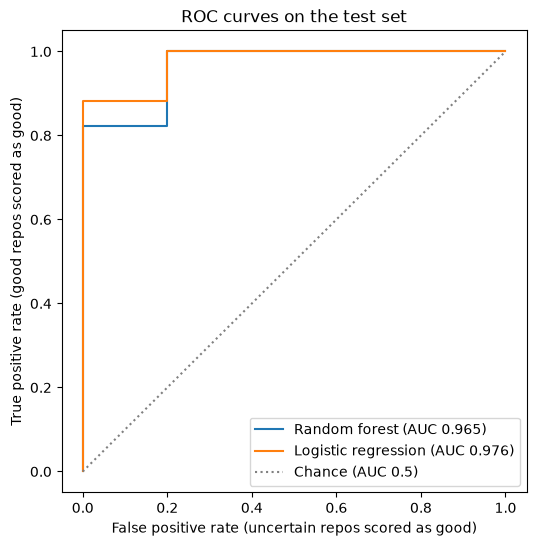

In [9]:
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_probabilities)
logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(y_test, logistic_probabilities)

plt.figure(figsize=(6, 6))
plt.plot(rf_fpr, rf_tpr, label="Random forest (AUC " + str(round(rf_auc, 3)) + ")")
plt.plot(logistic_fpr, logistic_tpr, label="Logistic regression (AUC " + str(round(logistic_auc, 3)) + ")")
plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Chance (AUC 0.5)")
plt.xlabel("False positive rate (uncertain repos scored as good)")
plt.ylabel("True positive rate (good repos scored as good)")
plt.title("ROC curves on the test set")
plt.legend()
plt.show()

## Feature importance

Mean decrease in impurity from the tuned random forest: how much each signal contributed to the trees' splits. These importances are computed on training data and tend to favor continuous signals over binary ones, so they show what the model relied on, not proof of what causes quality.

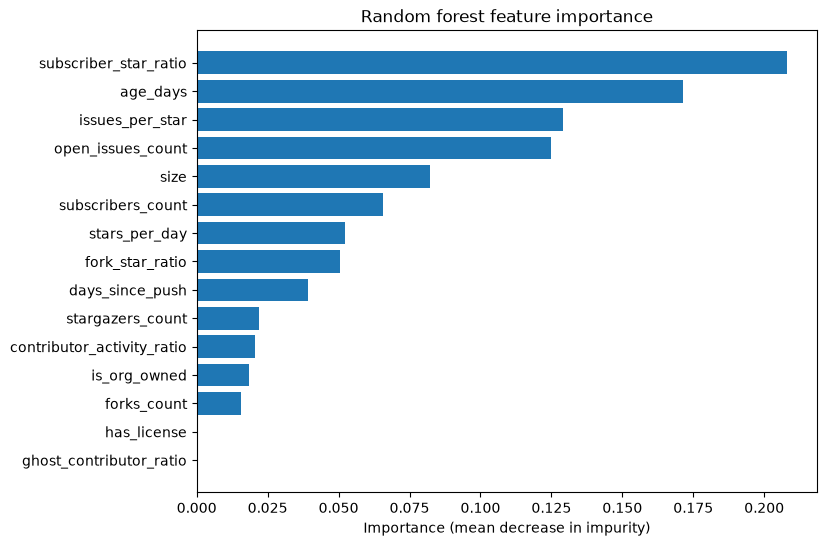

,signal,importance
8,subscriber_star_ratio,0.208
5,age_days,0.171
9,issues_per_star,0.129
3,open_issues_count,0.125
4,size,0.082
2,subscribers_count,0.066
10,stars_per_day,0.052
7,fork_star_ratio,0.050
6,days_since_push,0.039
0,stargazers_count,0.022


In [10]:
forest = best_model.named_steps["model"]

importances = pd.DataFrame()
importances["signal"] = signal_columns
importances["importance"] = forest.feature_importances_
importances = importances.sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(importances["signal"], importances["importance"])
plt.xlabel("Importance (mean decrease in impurity)")
plt.title("Random forest feature importance")
plt.show()

importances.sort_values("importance", ascending=False).round(3)

## Findings

**Results.** The random forest reaches 0.965 test ROC-AUC (cross-validation AUC 0.988 on the training set). The reproduced combined logistic regression reaches 0.976, and the strongest single signal, `age_days`, reaches 0.988. With only 5 uncertain repos in the test set, a difference of about 0.02 AUC corresponds to roughly one repo changing rank, so the three results should be treated as equivalent.

**Tuning.** A 36-combination grid search with 5-fold cross-validation on the training set did not improve on the default settings. The test set was used only once, for the final evaluation.

**Missing values.** The current split has no missing values. Median imputation is kept in the pipeline, fit on training data only, so the model handles missing values in future data.

**Feature importance.** The forest relies most on `subscriber_star_ratio`, `age_days`, `issues_per_star`, and `open_issues_count`. `has_license` and `ghost_contributor_ratio` contribute nothing because they are nearly constant in this dataset (almost every repo has a license and almost none have ghost contributors).

**Limitations.**

- The classes are separable by project maturity alone. Good repos are mostly long-established and uncertain repos are mostly new, so high AUC here may reflect how the lists were collected rather than repo quality. Combining signals cannot show added value on this split.
- The two misclassified good repos, `microsoft/promptflow` (0.41) and `microsoft/markitdown` (0.40), are newer projects with fast star growth. This is the bias the project aims to avoid: penalizing new but legitimate repos.
- One uncertain repo, `CodebuffAI/freebuff`, scored 0.59 and would be labeled good at a 0.5 threshold.
- The Part 3 script has not produced a result yet, so its configuration was reproduced here on Part 1's split.

**Next steps.**

- Build a harder evaluation set that compares good and uncertain repos of similar age and size.
- Add a neutral band (for example, probabilities between 0.35 and 0.65) that is reported as unknown rather than forced into good or uncertain. Four test repos fall in this range.
- Replace or rethink near-constant signals such as `has_license` and `ghost_contributor_ratio`.